<a href="https://colab.research.google.com/github/MALISMF/Intelligent-Agents-Graph-Networks-and-Other-Practical-Machine-Learning-Tasks/blob/main/homeworks/cora_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Установка и импорты

In [35]:
!pip install torch_geometric networkx scikit-learn
!pip install pyfglt

## Загрузка данных


In [36]:
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_networkx

# Загрузка набора данных Cora
dataset = Planetoid('.', 'Cora')
data = dataset[0]

# Преобразование в граф networkx
G = to_networkx(data, to_undirected=True)

# Вывод информации о загруженных данных и графе
print(f'Набор данных: {dataset}')
print(f'Количество графов: {len(dataset)}')
print(f'Количество признаков: {dataset.num_features}')
print(f'Количество классов: {dataset.num_classes}')
print(f'Граф: {G}')
print(f'Количество узлов: {G.number_of_nodes()}')
print(f'Количество ребер: {G.number_of_edges()}')

Набор данных: Cora()
Количество графов: 1
Количество признаков: 1433
Количество классов: 7
Граф: Graph with 2708 nodes and 5278 edges
Количество узлов: 2708
Количество ребер: 5278


In [37]:
# Извлечение истинных меток классов и преобразование в numpy int массив
true_labels = data.y.cpu().numpy().astype(int)

# Вывод первых нескольких элементов и размера true_labels
print("Первые 10 истинных меток:", true_labels[:10])
print("Размер true_labels:", true_labels.shape)

Первые 10 истинных меток: [3 4 4 0 3 2 0 3 3 2]
Размер true_labels: (2708,)


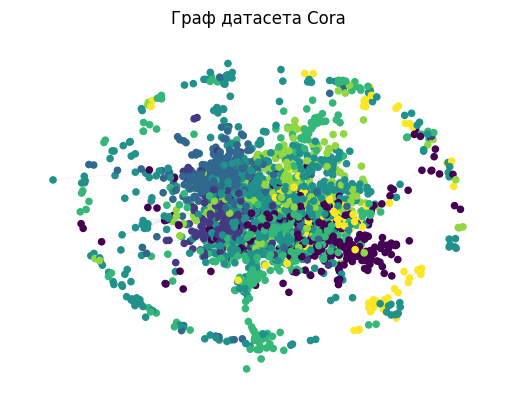

In [38]:
import networkx as nx
import matplotlib.pyplot as plt


pos = nx.spring_layout(G, seed = 42)
nx.draw_networkx_nodes(G, pos, node_size=20, node_color=true_labels,  cmap=plt.cm.viridis)
nx.draw_networkx_edges(G, pos, width=0.1, edge_color='gray', alpha=0.5)
plt.title('Граф датасета Cora')
plt.axis('off')
plt.show()

## Вариант 1 (центральности + pagerank)


In [39]:
import networkx as nx
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import matplotlib.pyplot as plt

In [40]:
# 1. Вычисление центральностей (степени, посредничества, близости, собственного вектора) и PageRank
degree_centrality = np.array(list(nx.degree_centrality(G).values()))
betweenness_centrality = np.array(list(nx.betweenness_centrality(G).values()))
closeness_centrality = np.array(list(nx.closeness_centrality(G).values()))
eigenvector_centrality = np.array(list(nx.eigenvector_centrality(G).values()))
pagerank = np.array(list(nx.pagerank(G).values()))

In [41]:

# 2. Объединение признаков
X_centralities = np.vstack([degree_centrality, betweenness_centrality, closeness_centrality, eigenvector_centrality, pagerank]).T

# 3. Применение log1p
X_centralities_log = np.log1p(X_centralities)

# 4. Инициализация и применение StandardScaler
scaler = StandardScaler()
X_centralities_scaled = scaler.fit_transform(X_centralities_log)

# 5. Инициализация и применение PCA
pca = PCA(n_components=0.95)
X_pca_centralities = pca.fit_transform(X_centralities_scaled)
print(f"Применен PCA. Исходные размерности: {X_centralities_scaled.shape[1]}, Уменьшенные размерности: {X_pca_centralities.shape[1]}")


Применен PCA. Исходные размерности: 5, Уменьшенные размерности: 3


In [42]:
# 6. Подбор k для K-means (от 2 до 21)
best_k, best_s, labels = None, -1, None
for k in range(2, 22):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    current_labels = kmeans.fit_predict(X_pca_centralities)
    current_s = silhouette_score(X_pca_centralities, current_labels)
    if current_s > best_s:
        best_k, best_s, labels = k, current_s, current_labels

# 7. Оценка качества кластеризации
sil = silhouette_score(X_pca_centralities, labels)
ari = adjusted_rand_score(true_labels, labels)

# 8. Вывод результатов
print(f"Лучшее k: {best_k}")
print(f"Silhouette Score: {sil:.4f}")
print(f"Adjusted Rand Index: {ari:.4f}")


Лучшее k: 2
Silhouette Score: 0.9193
Adjusted Rand Index: -0.0002


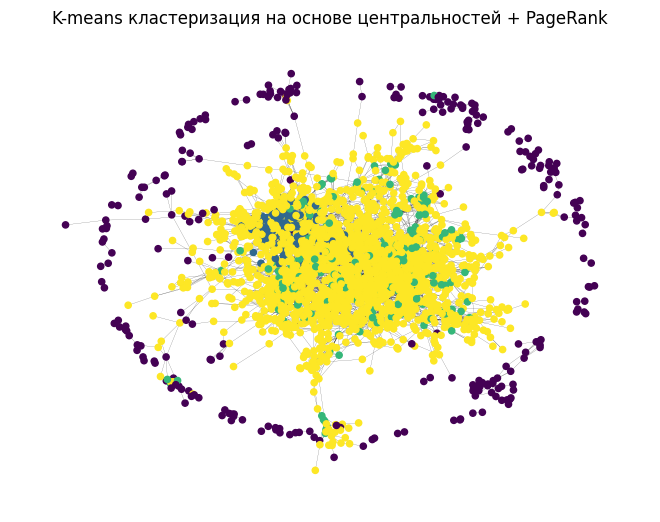

In [43]:
# 9. Визуализация результатов
pos = nx.spring_layout(G, seed=42) # Генерация позиций узлов
nx.draw(G, pos, node_size=20, node_color=labels_combined, cmap=plt.cm.viridis, width=0.1)
plt.title('K-means кластеризация на основе центральностей + PageRank')
plt.axis('off')
plt.show()

## Вариант 2 (Графлеты)

In [44]:
import pyfglt.fglt as fg

In [45]:
# 1. Извлечение признаков графлетов
X_graphlets = np.array(fg.compute(G))
print(f"Извлечены признаки графлетов с формой: {X_graphlets.shape}")


Извлечены признаки графлетов с формой: (2708, 16)


In [46]:
# 2. Применение log1p
X_graphlets_log = np.log1p(X_graphlets)

# 3. Инициализация и применение StandardScaler
scaler_graphlets = StandardScaler()
X_graphlets_scaled = scaler_graphlets.fit_transform(X_graphlets_log)

# 4. Инициализация и применение PCA
pca_graphlets = PCA(n_components=0.95)
X_pca_graphlets = pca_graphlets.fit_transform(X_graphlets_scaled)
print(f"Применен PCA к признакам графлетов. Исходные размерности: {X_graphlets_scaled.shape[1]}, Уменьшенные размерности: {X_pca_graphlets.shape[1]}")


Применен PCA к признакам графлетов. Исходные размерности: 16, Уменьшенные размерности: 7


In [47]:

# 5. Подбор k для K-means (от 2 до 21)
best_k_graphlets, best_s_graphlets, labels_graphlets = None, -1, None
for k in range(2, 22):
    kmeans_graphlets = KMeans(n_clusters=k, n_init=10, random_state=42)
    current_labels_graphlets = kmeans_graphlets.fit_predict(X_pca_graphlets)
    current_s_graphlets = silhouette_score(X_pca_graphlets, current_labels_graphlets)
    if current_s_graphlets > best_s_graphlets:
        best_k_graphlets, best_s_graphlets, labels_graphlets = k, current_s_graphlets, current_labels_graphlets

# 6. Оценка качества кластеризации
sil_graphlets = silhouette_score(X_pca_graphlets, labels_graphlets)
ari_graphlets = adjusted_rand_score(true_labels, labels_graphlets)

# 7. Вывод результатов
print("\n--- Результаты кластеризации по признакам графлетов pyfglt.fglt ---")
print(f"Лучшее k: {best_k_graphlets}")
print(f"Silhouette Score: {sil_graphlets:.4f}")
print(f"Adjusted Rand Index: {ari_graphlets:.4f}")



--- Результаты кластеризации по признакам графлетов pyfglt.fglt ---
Лучшее k: 2
Silhouette Score: 0.3912
Adjusted Rand Index: 0.0178


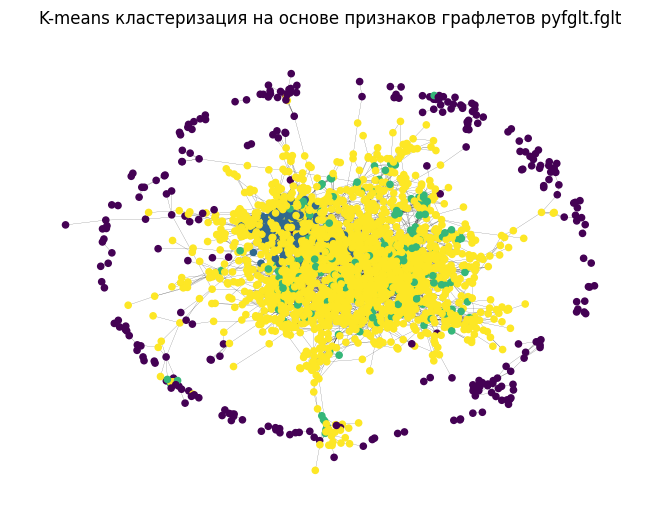

In [34]:

# 8. Визуализация результатов
pos = nx.spring_layout(G, seed=42) # Генерация позиций узлов
nx.draw(G, pos, node_size=20, node_color=labels_combined, cmap=plt.cm.viridis, width=0.1)
plt.title('K-means кластеризация на основе признаков графлетов pyfglt.fglt')
plt.axis('off')
plt.show()

## Вариант 3 (Комбинированные признаки)

In [48]:
# 1. Объединение признаков из Варианта 1 и Варианта 2
X_combined = np.hstack((X_pca_centralities, X_pca_graphlets))
print(f"Форма объединенных признаков: {X_combined.shape}")

Форма объединенных признаков: (2708, 10)


In [49]:
# 2. Инициализация и применение StandardScaler
scaler_combined = StandardScaler()
X_combined_scaled = scaler_combined.fit_transform(X_combined)

# 3. Инициализация и применение PCA
pca_combined = PCA(n_components=0.95)
X_pca_combined = pca_combined.fit_transform(X_combined_scaled)
print(f"Применен PCA к объединенным признакам. Исходные размерности: {X_combined_scaled.shape[1]}, Уменьшенные размерности: {X_pca_combined.shape[1]}")


Применен PCA к объединенным признакам. Исходные размерности: 10, Уменьшенные размерности: 8


In [50]:
# 4. Подбор k для K-means (от 2 до 21)
best_k_combined, best_s_combined, labels_combined = None, -1, None
for k in range(2, 22):
    kmeans_combined = KMeans(n_clusters=k, n_init=10, random_state=42)
    current_labels_combined = kmeans_combined.fit_predict(X_pca_combined)
    current_s_combined = silhouette_score(X_pca_combined, current_labels_combined)
    if current_s_combined > best_s_combined:
        best_k_combined, best_s_combined, labels_combined = k, current_s_combined, current_labels_combined

# 5. Оценка качества кластеризации
sil_combined = silhouette_score(X_pca_combined, labels_combined)
ari_combined = adjusted_rand_score(true_labels, labels_combined)

# 6. Вывод результатов
print("\n--- Результаты кластеризации по объединенным признакам ---")
print(f"Лучшее k: {best_k_combined}")
print(f"Silhouette Score: {sil_combined:.4f}")
print(f"Adjusted Rand Index: {ari_combined:.4f}")


--- Результаты кластеризации по объединенным признакам ---
Лучшее k: 4
Silhouette Score: 0.3010
Adjusted Rand Index: 0.0137


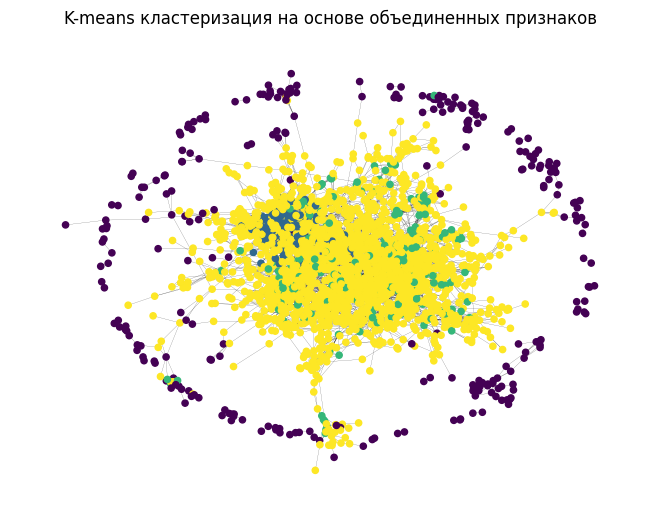

In [51]:
# 7. Визуализация результатов
pos = nx.spring_layout(G, seed=42) # Генерация позиций узлов
nx.draw(G, pos, node_size=20, node_color=labels_combined, cmap=plt.cm.viridis, width=0.1)
plt.title('K-means кластеризация на основе объединенных признаков')
plt.axis('off')
plt.show()

#Вывод

In [52]:
import pandas as pd

# Создание DataFrame с результатами
results_data = {
    'Метод': ['Центральности + PageRank', 'Графлеты', 'Комбинированные признаки'],
    'Лучшее k': [best_k, best_k_graphlets, best_k_combined],
    'Silhouette Score': [sil, sil_graphlets, sil_combined],
    'Adjusted Rand Index': [ari, ari_graphlets, ari_combined]
}

results_df = pd.DataFrame(results_data)

print("Таблица результатов кластеризации")
display(results_df)

Таблица результатов кластеризации


,Метод,Лучшее k,Silhouette Score,Adjusted Rand Index
0,Центральности + PageRank,2,0.919328,-0.000175
1,Графлеты,2,0.391182,0.017788
2,Комбинированные признаки,4,0.301037,0.013681


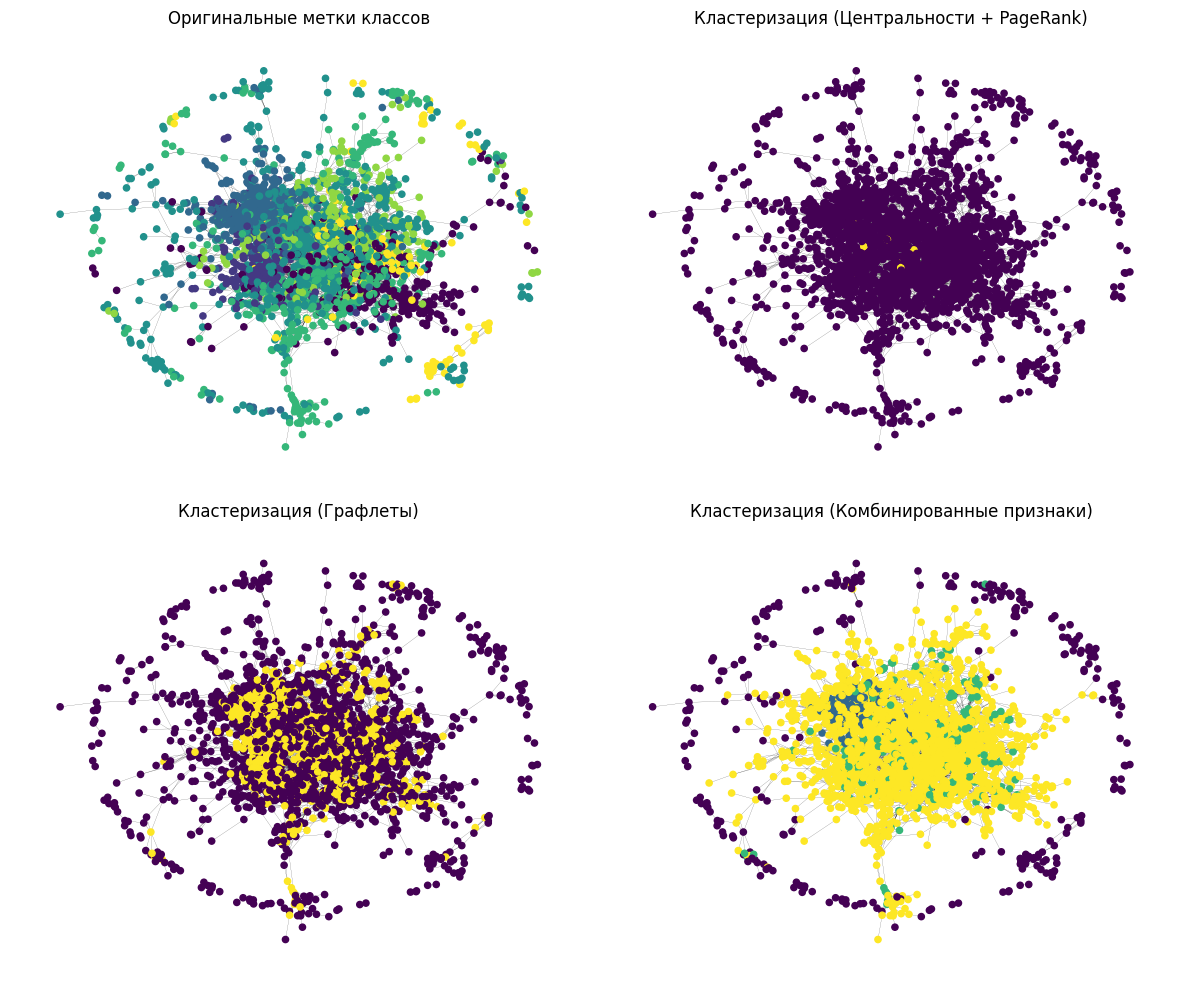

In [53]:
# 9. Визуализация результатов для всех четырех случаев
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Оригинальные метки
ax = axes[0, 0]
nx.draw(G, pos, node_size=20, node_color=true_labels, cmap=plt.cm.viridis, width=0.1, ax=ax)
ax.set_title('Оригинальные метки классов')
ax.axis('off')

# Кластеризация по центральностям + PageRank
ax = axes[0, 1]
nx.draw(G, pos, node_size=20, node_color=labels, cmap=plt.cm.viridis, width=0.1, ax=ax)
ax.set_title('Кластеризация (Центральности + PageRank)')
ax.axis('off')

# Кластеризация по графлетам
ax = axes[1, 0]
nx.draw(G, pos, node_size=20, node_color=labels_graphlets, cmap=plt.cm.viridis, width=0.1, ax=ax)
ax.set_title('Кластеризация (Графлеты)')
ax.axis('off')

# Кластеризация по комбинированным признакам
ax = axes[1, 1]
nx.draw(G, pos, node_size=20, node_color=labels_combined, cmap=plt.cm.viridis, width=0.1, ax=ax)
ax.set_title('Кластеризация (Комбинированные признаки)')
ax.axis('off')

plt.tight_layout()
plt.show()